In [31]:
import os
import sys
import h5py
# import yaml
# import types
# import torch
import numpy as np
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [32]:
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)

## Load IT neuron firing rate

In [33]:
neural_data_pth = os.path.join(REPO_ROOT, 'data/forJhan/data/MergedITCells_500Stim_AxisTuned.mat')

with h5py.File(neural_data_pth, 'r') as f:
    responses = f['responses']
    # Build full (386 x 500) matrix once
    neural_matrix = np.stack([f[responses[0, i]][()].flatten() for i in range(386)])  # (386, 500)

## Encode stimuli images

In [34]:
alexnet_fc6_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_alexnet_fc6_pca_latents/val_latents.npy"))

In [46]:
clip_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_clip_vit_b32_pca_latents/val_latents_z50.npy"))

## Axis tuning analysis

For each of the 386 IT neurons, estimate its preferred axis in AlexNet fc6 (PCA'd) space, cross-validated explained variance along that axis, and a selectivity index comparing it to an orthogonal control axis.

In [35]:
from analysis.sta_analysis import (
    compute_population_axis_tuning,
    compute_orthogonal_variance,
    compute_sta,
)

In [56]:
stimuli_embeddings = alexnet_fc6_latents

axis_tuning_results = compute_population_axis_tuning(
    neural_matrix, stimuli_embeddings, method='sta'
)

ev = axis_tuning_results['explained_variance']
sel = axis_tuning_results['selectivity_index']

print(f"Neurons: {neural_matrix.shape[0]}, Stimuli: {neural_matrix.shape[1]}, Feature dims: {alexnet_fc6_latents.shape[1]}")
print(f"Mean CV explained variance: {ev.mean():.3f} (median {np.median(ev):.3f})")
print(f"Mean selectivity index: {sel.mean():.3f} (median {np.median(sel):.3f})")
print(f"Neurons with EV > 0.1: {(ev > 0.1).sum()}/{len(ev)}")
print(f"Neurons with EV > 0.1 and selectivity > 0.5: {((ev > 0.1) & (sel > 0.5)).sum()}/{len(ev)}")
print(f"Mean pairwise preferred-axis angle: {axis_tuning_results['mean_pairwise_angle_deg']:.1f} deg")

Axis tuning (sta): 100%|██████████| 386/386 [01:07<00:00,  5.73it/s]

Neurons: 386, Stimuli: 500, Feature dims: 50
Mean CV explained variance: 0.168 (median 0.124)
Mean selectivity index: 1.000 (median 1.000)
Neurons with EV > 0.1: 231/386
Neurons with EV > 0.1 and selectivity > 0.5: 231/386
Mean pairwise preferred-axis angle: 61.7 deg


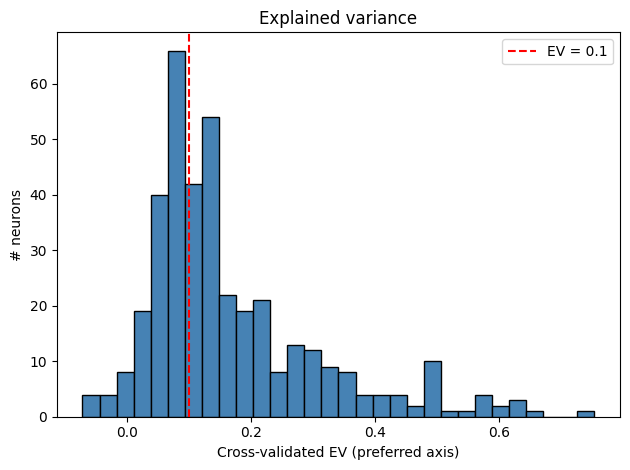

In [57]:
# fig, axes_ = plt.subplots(1, 3, figsize=(15, 4))

# axes_[0].hist(ev, bins=30, color='steelblue', edgecolor='black')
# axes_[0].axvline(0.1, color='red', linestyle='--', label='EV = 0.1')
# axes_[0].set_xlabel('Cross-validated EV (preferred axis)')
# axes_[0].set_ylabel('# neurons')
# axes_[0].set_title('Explained variance')
# axes_[0].legend()

# axes_[1].hist(sel, bins=30, color='seagreen', edgecolor='black')
# axes_[1].axvline(0.5, color='red', linestyle='--', label='selectivity = 0.5')
# axes_[1].set_xlabel('Selectivity index')
# axes_[1].set_title('Axis selectivity')
# axes_[1].legend()

# axes_[2].scatter(ev, sel, alpha=0.6, s=20, c=sel, cmap='RdYlGn')
# axes_[2].axhline(0.5, color='red', linestyle='--', linewidth=1)
# axes_[2].axvline(0.1, color='blue', linestyle='--', linewidth=1)
# axes_[2].set_xlabel('Explained variance')
# axes_[2].set_ylabel('Selectivity index')
# axes_[2].set_title('EV vs. selectivity')

plt.hist(ev, bins=30, color='steelblue', edgecolor='black')
plt.axvline(0.1, color='red', linestyle='--', label='EV = 0.1')
plt.xlabel('Cross-validated EV (preferred axis)')
plt.ylabel('# neurons')
plt.title('Explained variance')
plt.legend()

plt.tight_layout()
plt.show()

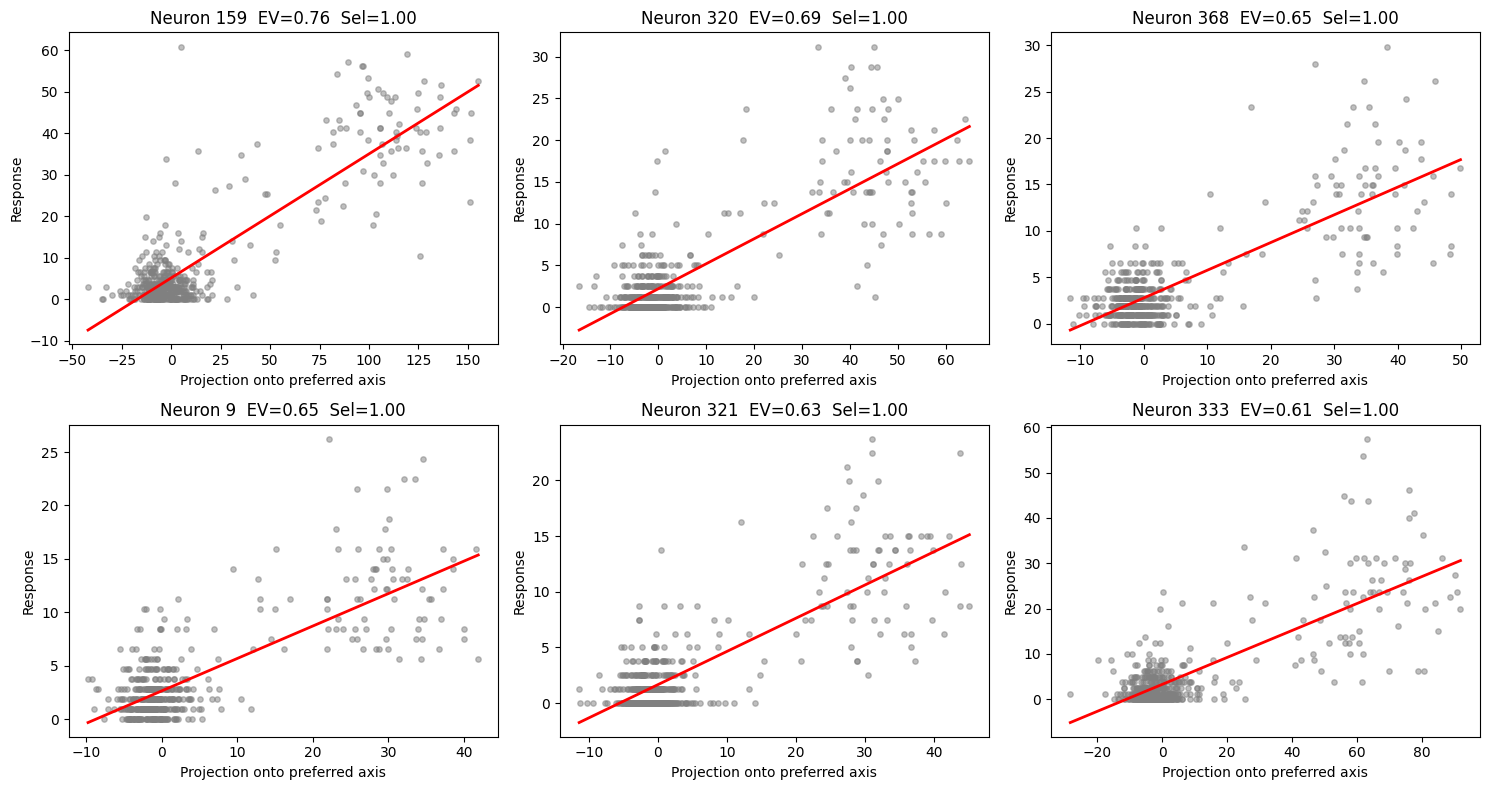

In [49]:
top_units = np.argsort(ev)[-6:][::-1]

fig, axes_ = plt.subplots(2, 3, figsize=(15, 8))
for ax, unit_idx in zip(axes_.flatten(), top_units):
    resp = neural_matrix[unit_idx, :]
    axis, _ = compute_sta(resp, alexnet_fc6_latents, method='sta', normalize=True)
    orth = compute_orthogonal_variance(resp, alexnet_fc6_latents, axis)
    proj_pref = orth['proj_pref']

    coeffs = np.polyfit(proj_pref, resp, 1)
    x_sorted = np.sort(proj_pref)
    ax.scatter(proj_pref, resp, alpha=0.5, s=15, color='gray')
    ax.plot(x_sorted, np.polyval(coeffs, x_sorted), 'r-', linewidth=2)
    ax.set_title(f"Neuron {unit_idx}  EV={ev[unit_idx]:.2f}  Sel={sel[unit_idx]:.2f}")
    ax.set_xlabel('Projection onto preferred axis')
    ax.set_ylabel('Response')

plt.tight_layout()
plt.show()

### Rank of preferred-axis matrix W

Each row of `W` is one neuron's preferred axis in the 50-dim embedding space. Recovering a stimulus embedding from the population response requires `rank(W) = 50` (see population axis-tuning discussion) — otherwise some embedding directions lie in `W`'s null space and are invisible to the whole population regardless of neuron count.

In [50]:
W = axis_tuning_results['axes']  # (386 neurons, 50 feature dims)
rank_W = np.linalg.matrix_rank(W)

print(f"W shape: {W.shape}")
print(f"rank(W) = {rank_W} (full column rank = {W.shape[1]})")
print(f"Null space dimension: {W.shape[1] - rank_W}")

W shape: (386, 50)
rank(W) = 50 (full column rank = 50)
Null space dimension: 0


## Firing rates $\to$ image embeddings

In [51]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from analysis.sta_analysis import compute_explained_variance

In [58]:
# Train/test split over the 500 stimuli
rng = np.random.default_rng(0)
n_stim = neural_matrix.shape[1]
perm = rng.permutation(n_stim)
n_test = int(0.2 * n_stim)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train, X_test = neural_matrix[:, train_idx].T, neural_matrix[:, test_idx].T  # (n_stim, 386 neurons)
y_train, y_test = stimuli_embeddings[train_idx], stimuli_embeddings[test_idx]  # (n_stim, 50)

In [59]:
def evaluate(y_pred, label):
    dim_ev = np.array([compute_explained_variance(y_test[:, d], y_pred[:, d]) for d in range(y_test.shape[1])])
    overall_ev = compute_explained_variance(y_test.flatten(), y_pred.flatten())
    print(f"{label}: held-out EV (flattened):={overall_ev:.3f}") 
    print(f"Per-dimension EV: mean={dim_ev.mean():.3f}, median={np.median(dim_ev):.3f}") 
    print(f"Dimensions with EV > 0.1: {int((dim_ev>0.1).sum())}/50")
    return dim_ev

In [60]:
# # original: unscaled, fixed alpha=100
# d1 = Ridge(alpha=100.0).fit(X_train, y_train)
# evaluate(d1.predict(X_test), "raw Ridge alpha=100")

# # standardized features, same fixed alpha
# pipe = make_pipeline(StandardScaler(), Ridge(alpha=100.0)).fit(X_train, y_train)
# evaluate(pipe.predict(X_test), "scaled Ridge alpha=100")

# standardized features + cross-validated alpha per target dimension
scaler = StandardScaler().fit(X_train)
Xtr_s, Xte_s = scaler.transform(X_train), scaler.transform(X_test)
rcv = RidgeCV(alphas=np.logspace(-1, 6, 30), alpha_per_target=True).fit(Xtr_s, y_train)
y_pred = rcv.predict(Xte_s)
dim_ev = evaluate(y_pred, "scaled RidgeCV (alpha_per_target)")
print("chosen alphas range:", rcv.alpha_.min(), rcv.alpha_.max())

scaled RidgeCV (alpha_per_target): held-out EV (flattened):=0.281
Per-dimension EV: mean=0.146, median=0.087
Dimensions with EV > 0.1: 22/50
chosen alphas range: 417.53189365604044 11721.022975334818


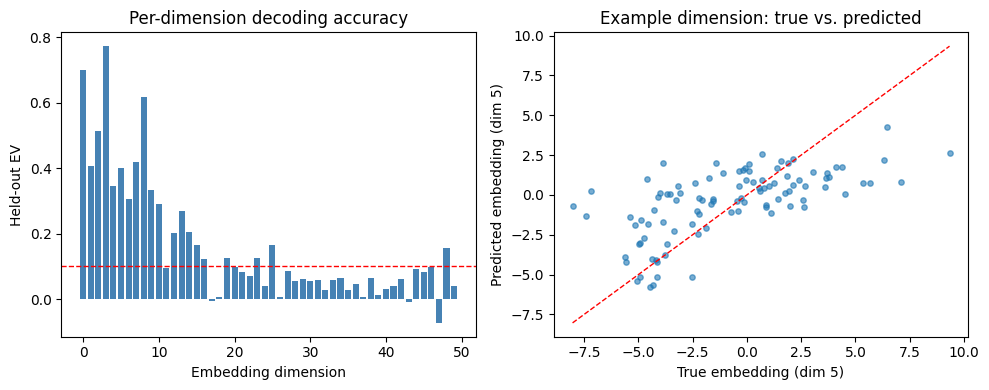

In [55]:
example_dim = 5

fig, axes_ = plt.subplots(1, 2, figsize=(10, 4))

axes_[0].bar(np.arange(len(dim_ev)), dim_ev, color='steelblue')
axes_[0].axhline(0.1, color='red', linestyle='--', linewidth=1)
axes_[0].set_xlabel('Embedding dimension')
axes_[0].set_ylabel('Held-out EV')
axes_[0].set_title('Per-dimension decoding accuracy')

axes_[1].scatter(y_test[:, example_dim], y_pred[:, example_dim], alpha=0.6, s=15)
lims = [min(y_test[:, example_dim].min(), y_pred[:, example_dim].min()), max(y_test[:, example_dim].max(), y_pred[:, example_dim].max())]
axes_[1].plot(lims, lims, 'r--', linewidth=1)
axes_[1].set_xlabel(f'True embedding (dim {example_dim})')
axes_[1].set_ylabel(f'Predicted embedding (dim {example_dim})')
axes_[1].set_title('Example dimension: true vs. predicted')

plt.tight_layout()
plt.show()